In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from importlib.metadata import version
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, validation_curve
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pickle

print(f"Pandas: {version('pandas')}")
print(f"Numpy: {version('numpy')}")
print(f"Matplotlib: {version('matplotlib')}")
print(f"Seaborn: {version('seaborn')}")
print(f"Scikit-learn: {version('scikit-learn')}")


Pandas: 3.0.0
Numpy: 1.26.4
Matplotlib: 3.10.8
Seaborn: 0.13.2
Scikit-learn: 1.8.0


In [8]:
data = pd.read_csv('../L1 Regresion Lineal/data/Datos Lab 1.csv')
data = data.copy()

print("=" * 70)
print("Preparación de datos")
print("=" * 70)
print(f"Registros iniciales: {data.shape[0]}")

duplicados = data.duplicated().sum()
print(f"Duplicados: {duplicados}")
data = data.drop_duplicates()
print(f"Registros después de eliminar duplicados: {data.shape[0]}")

data = data.dropna(subset=['CVD Risk Score'])
print(f"Registros después de eliminar filas con NA en 'CVD Risk Score': {data.shape[0]}")

print("Sección de variables:")
variables_objetivo = 'CVD Risk Score'
variables_excluir = ['Patient ID', 'Date of Service', 'Blood Pressure (mmHg)', 'Height (m)', 'Height (cm)', 'CVD Risk Level']
print(f"Variables excluidas: {variables_excluir}")

X = data.drop(columns=variables_excluir + [variables_objetivo])
y = data[variables_objetivo]

print(f"Variables seleccionadas para el modelo: {X.shape[1]}")
print(X.columns.tolist())

variables_numericas = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
variables_categoricas = X.select_dtypes(include=['object']).columns.tolist()
print(f"Variables numericas ({len(variables_numericas)}): {variables_numericas}")
print(f"Variables categoricas ({len(variables_categoricas)}): {variables_categoricas}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"Tamaño conjunto entrenamiento: {X_train.shape[0]} ({100*X_train.shape[0]/X.shape[0]:.1f}%)")
print(f"Tamaño conjunto prueba: {X_test.shape[0]} ({100*X_test.shape[0]/X.shape[0]:.1f}%)")

preprocesamiento_completo = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputador', SimpleImputer(strategy='median')),
            ('escalador', StandardScaler())
            
        ]),variables_numericas),
        ('cat', Pipeline(steps=[
            ('imputador', SimpleImputer(strategy='most_frequent')),
            ('codificador', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]),variables_categoricas)
    ])

X_train_prep = preprocesamiento_completo.fit_transform(X_train)
X_test_prep = preprocesamiento_completo.transform(X_test)

print(f"Dimensiones despues del procesamiento: {X_train_prep.shape}")




Preparación de datos
Registros iniciales: 1639
Duplicados: 151
Registros después de eliminar duplicados: 1488
Registros después de eliminar filas con NA en 'CVD Risk Score': 1460
Sección de variables:
Variables excluidas: ['Patient ID', 'Date of Service', 'Blood Pressure (mmHg)', 'Height (m)', 'Height (cm)', 'CVD Risk Level']
Variables seleccionadas para el modelo: 17
['Sex', 'Age', 'Weight (kg)', 'BMI', 'Abdominal Circumference (cm)', 'Total Cholesterol (mg/dL)', 'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)', 'Smoking Status', 'Diabetes Status', 'Physical Activity Level', 'Family History of CVD', 'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP', 'Blood Pressure Category', 'Estimated LDL (mg/dL)']
Variables numericas (11): ['Age', 'Weight (kg)', 'BMI', 'Abdominal Circumference (cm)', 'Total Cholesterol (mg/dL)', 'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)', 'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP', 'Estimated LDL (mg/dL)']
Variables categoricas (6): ['Sex', 'Smoking 

In [9]:
print("=" * 70)
print("Modelo 1: Regresión Polinomial")
print("=" * 70)

prep_poly = Pipeline(steps=[
    ('imputador', SimpleImputer(strategy='median')),
    ('escalador', StandardScaler())
])

X_train_poly = prep_poly.fit_transform(X_train[variables_numericas])
X_test_poly = prep_poly.transform(X_test[variables_numericas])

param_grid_poly = {
    'poly_degree': [1, 2, 3, 4, 5],
}

resultados_poly = []

for degree in param_grid_poly['poly_degree']:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly_feat = poly.fit_transform(X_train_poly)
    X_test_poly_feat = poly.transform(X_test_poly)
    
    modelo = LinearRegression()
    modelo.fit(X_train_poly_feat, y_train)
    
    y_pred_train = modelo.predict(X_train_poly_feat)
    y_pred_test = modelo.predict(X_test_poly_feat)
    
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    mae_train = mean_absolute_error(y_train, y_pred_train)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    
    cv_resultados = cross_val_score(LinearRegression(), X_train_poly_feat, y_train, cv=5, scoring='neg_mean_squared_error')
    rmse_cv = np.sqrt(-cv_resultados.mean())
    rmse_cv_scores = np.sqrt(-cv_resultados)
    rmse_cv_std = rmse_cv_scores.std()
    
    resultados_poly.append({
        'degree': degree,
        'n_features': X_train_poly_feat.shape[1],
        'rmse_train': rmse_train,
        'rmse_test': rmse_test,
        'mae_train': mae_train,
        'mae_test': mae_test,
        'r2_train': r2_train,
        'r2_test': r2_test,
        'rmse_cv': rmse_cv,
        'rmse_cv_std': rmse_cv_std,
        'modelo': modelo,
        'poly': poly,
        'X_train_poly_feat': X_train_poly_feat,
        'X_test_poly_feat': X_test_poly_feat
    })
    
df_poly = pd.DataFrame([{
    'Grado': r['degree'],
    'Características': r['n_features'],
    'RMSE Entrenamiento': r['rmse_train'],
    'RMSE Prueba': r['rmse_test'],
    'MAE Entrenamiento': r['mae_train'],
    'MAE Prueba': r['mae_test'],
    'R² Entrenamiento': r['r2_train'],
    'R² Prueba': r['r2_test'],
    'RMSE CV media': r['rmse_cv'],
    'RMSE CV Std': r['rmse_cv_std']
} for r in resultados_poly])

print("\nResultados de Regresión Polinomial:")
print(df_poly.to_string(index=False))

mejor_poly = resultados_poly[np.argmin([r['rmse_cv'] for r in resultados_poly])]
print(f"\nMejor grado polinomial: {mejor_poly['degree']} (RMSE CV: {mejor_poly['rmse_cv']:.4f})")


Modelo 1: Regresión Polinomial

Resultados de Regresión Polinomial:
 Grado  Características  RMSE Entrenamiento  RMSE Prueba  MAE Entrenamiento  MAE Prueba  R² Entrenamiento   R² Prueba  RMSE CV media  RMSE CV Std
     1               11           10.695619    10.765521           3.513084    3.683505          0.033604    0.004376      10.863488     3.566301
     2               77           10.336098    11.430409           4.068764    4.599749          0.097481   -0.122404      11.197702     3.183183
     3              363            8.942892    17.488738           4.545185    8.988398          0.324385   -1.627498      40.501418    21.645167
     4             1364            2.786322   327.751385           0.649573  130.629033          0.934415 -921.814817      93.884639    13.568787
     5             4367            2.786322    45.167475           0.649573   23.394382          0.934415  -16.525770      48.187142    10.348394

Mejor grado polinomial: 1 (RMSE CV: 10.8635)



CURVAS DE VALIDACIÓN - POLINOMIAL


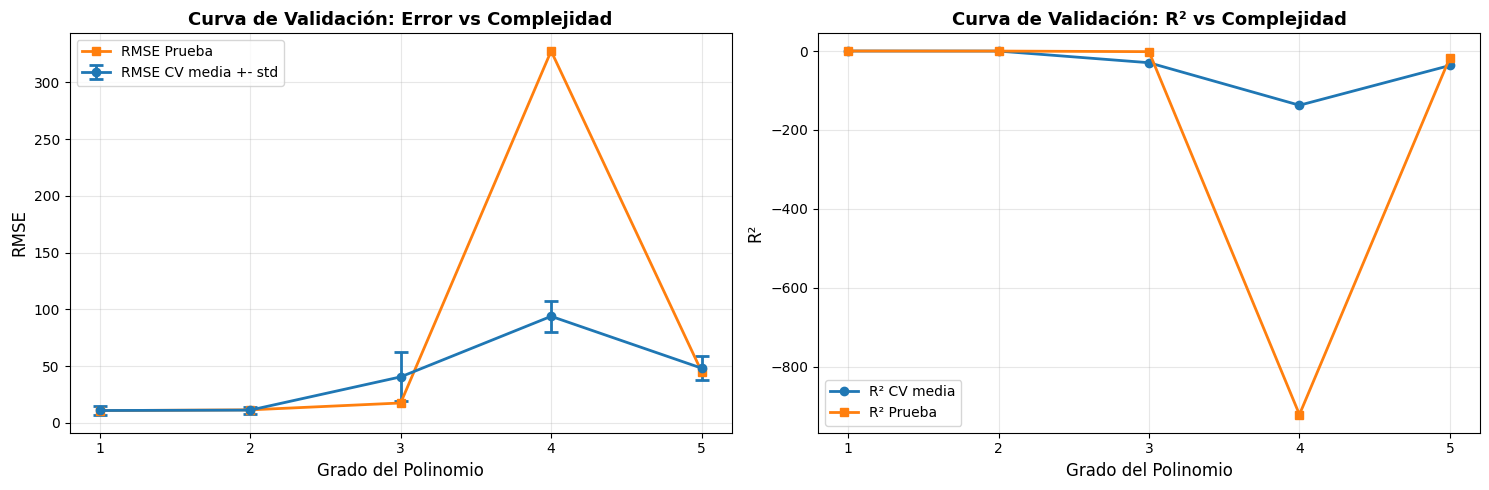


Interpretación:
- Observe cómo cambia RMSE a medida que aumenta la complejidad
- Identifique el punto donde comienza el sobreajuste (RMSE CV crece)
- Analice el trade-off sesgo-varianza


In [10]:
print("\n" + "=" * 70)
print("CURVAS DE VALIDACIÓN - POLINOMIAL")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

degrees = [r['degree'] for r in resultados_poly]
rmse_cv_means = [r['rmse_cv'] for r in resultados_poly]
rmse_cv_stds = [r['rmse_cv_std'] for r in resultados_poly]
rmse_test = [r['rmse_test'] for r in resultados_poly]

axes[0].errorbar(degrees, rmse_cv_means, yerr=rmse_cv_stds, marker='o', capsize=5, capthick=2, label='RMSE CV media +- std', linewidth=2)
axes[0].plot(degrees, rmse_test, marker='s', label='RMSE Prueba', linewidth=2)
axes[0].set_xlabel('Grado del Polinomio', fontsize=12)
axes[0].set_ylabel('RMSE', fontsize=12)
axes[0].set_title('Curva de Validación: Error vs Complejidad', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(degrees)

r2_cv_means = []
for degree in degrees:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly_feat = poly.fit_transform(X_train_poly)
    cv_scores = cross_val_score(LinearRegression(), X_train_poly_feat, y_train, cv=5, scoring='r2')
    r2_cv_means.append(cv_scores.mean())
    
r2_test = [r['r2_test'] for r in resultados_poly]

axes[1].plot(degrees, r2_cv_means, marker='o', label='R² CV media', linewidth=2)
axes[1].plot(degrees, r2_test, marker='s', label='R² Prueba', linewidth=2)
axes[1].set_xlabel('Grado del Polinomio', fontsize=12)
axes[1].set_ylabel('R²', fontsize=12)
axes[1].set_title('Curva de Validación: R² vs Complejidad', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(degrees)

plt.tight_layout()
plt.show()

print("\nInterpretación:")
print("- Observe cómo cambia RMSE a medida que aumenta la complejidad")
print("- Identifique el punto donde comienza el sobreajuste (RMSE CV crece)")
print("- Analice el trade-off sesgo-varianza")

In [11]:
print("\n" + "=" * 70)
print("MODELO 2: REGRESIÓN LINEAL (BASELINE - Sin regularización)")
print("=" * 70)

X_train_num = X_train[variables_numericas].fillna(X_train[variables_numericas].median())
X_test_num = X_test[variables_numericas].fillna(X_train[variables_numericas].median())

pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

pipeline_lr.fit(X_train_num, y_train)

y_pred_lr = pipeline_lr.predict(X_test_num)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

cv_scores_lr = cross_val_score(pipeline_lr, X_train_num, y_train, cv=5, scoring='neg_mean_squared_error')
rmse_cv_lr = np.sqrt(-cv_scores_lr.mean())
rmse_cv_std_lr_scores = np.sqrt(-cv_scores_lr)
rmse_cv_std_lr = rmse_cv_std_lr_scores.std()

print(f"RMSE CV: {rmse_cv_lr:.4f} ± {rmse_cv_std_lr:.4f}")
print(f"RMSE Test: {rmse_lr:.4f}")
print(f"MAE Test: {mae_lr:.4f}")
print(f"R² Test: {r2_lr:.4f}")


MODELO 2: REGRESIÓN LINEAL (BASELINE - Sin regularización)
RMSE CV: 10.8635 ± 3.5663
RMSE Test: 10.7655
MAE Test: 3.6835
R² Test: 0.0044


In [12]:
print("\n" + "=" * 70)
print("MODELO 2: REGRESIÓN RIDGE (L2)")
print("=" * 70)

param_grid_ridge = {
    'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
}

pipeline_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

grid_search_ridge = GridSearchCV(
    pipeline_ridge,
    param_grid_ridge,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

X_train_num = X_train[variables_numericas].fillna(X_train[variables_numericas].median())
X_test_num = X_test[variables_numericas].fillna(X_train[variables_numericas].median())

grid_search_ridge.fit(X_train_num, y_train)

print(f"\nMejor para Ridge: {grid_search_ridge.best_params_['ridge__alpha']}")
print(f"Mejor RMSE CV: {np.sqrt(-grid_search_ridge.best_score_):.4f}")

y_pred_ridge = grid_search_ridge.predict(X_test_num)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"RMSE Test: {rmse_ridge:.4f}")
print(f"MAE Test: {mae_ridge:.4f}")
print(f"R² Test: {r2_ridge:.4f}")

modelo_ridge = grid_search_ridge.best_estimator_




MODELO 2: REGRESIÓN RIDGE (L2)
Fitting 5 folds for each of 7 candidates, totalling 35 fits

Mejor para Ridge: 1000
Mejor RMSE CV: 10.8466
RMSE Test: 10.7149
MAE Test: 3.7409
R² Test: 0.0137


In [13]:
print("\n" + "=" * 70)
print("MODELO 3: REGRESIÓN LASSO (L1)")
print("=" * 70)

param_grid_lasso = {
    'lasso__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
}

pipeline_lasso= Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=10000))
])

grid_search_lasso = GridSearchCV(
    pipeline_lasso,
    param_grid_lasso,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search_lasso.fit(X_train_num, y_train)

print(f"\nMejor para Lasso: {grid_search_lasso.best_params_['lasso__alpha']}")
print(f"Mejor RMSE CV: {np.sqrt(-grid_search_lasso.best_score_):.4f}")

y_pred_lasso = grid_search_lasso.predict(X_test_num)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"RMSE Test: {rmse_lasso:.4f}")
print(f"MAE Test: {mae_lasso:.4f}")
print(f"R² Test: {r2_lasso:.4f}")

lasso_model = grid_search_lasso.best_estimator_.named_steps['lasso']
coef_lasso = lasso_model.coef_

print(f"\nCoeficientes Lasso (α={grid_search_lasso.best_params_['lasso__alpha']}):")
variables_no_cero = 0
for var, coef in zip(variables_numericas, coef_lasso):
    if coef != 0:
        print(f"{var}: {coef:.4f}")
        variables_no_cero += 1

print(f"Variables con coeficiente ≠ 0: {variables_no_cero}/{len(variables_numericas)}")
print(f"Variables llevadas a cero: {len(variables_numericas) - variables_no_cero}")

modelo_lasso = grid_search_lasso.best_estimator_


MODELO 3: REGRESIÓN LASSO (L1)
Fitting 5 folds for each of 7 candidates, totalling 35 fits

Mejor para Lasso: 0.1
Mejor RMSE CV: 10.8383
RMSE Test: 10.7160
MAE Test: 3.6223
R² Test: 0.0135

Coeficientes Lasso (α=0.1):
Age: -0.4783
Weight (kg): -0.3404
BMI: 1.4752
Total Cholesterol (mg/dL): 0.3621
HDL (mg/dL): -0.2022
Fasting Blood Sugar (mg/dL): 0.0074
Waist-to-Height Ratio: -0.0772
Systolic BP: 0.9649
Diastolic BP: 0.1942
Variables con coeficiente ≠ 0: 9/11
Variables llevadas a cero: 2
